This notebook analyzes the final analysis-ready datasets created during the data preparation and feature engineering pipeline.

Two analytical datasets are used:

- `df_master`: order-level dataset with a grain of 1 row = 1 order
- `funnel_master`: marketing and sales funnel dataset with a grain of *1 row = 1 marketing lead

The objective of this notebook is to explore business patterns, identify meaningful relationships, evaluate customer and operational behavior, and generate insights that can later be translated into business recommendations and Power BI dashboards.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_master = pd.read_csv("../data/final/df_master.csv")
funnel_master = pd.read_csv("../data/final/funnel_master.csv")

print("df_master shape:", df_master.shape)
print("funnel_master shape:", funnel_master.shape)

df_master shape: (99441, 69)
funnel_master shape: (8000, 32)


When re-reading columns from a CSV, date columns can end up as `object` type. That is why I convert them back to `datetime`.

In [3]:
df_master_datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp",
    "customer_first_order_date",
    "customer_last_order_date"
]

for col in df_master_datetime_cols:
    df_master[col] = pd.to_datetime(
        df_master[col],
        errors="coerce"
    )

In [4]:
funnel_datetime_cols = [
    "first_contact_date",
    "won_date"
]

for col in funnel_datetime_cols:
    funnel_master[col] = pd.to_datetime(
        funnel_master[col],
        errors="coerce"
    )

These metrics provide a high-level view of the business before moving into more detailed sales, customer, logistics, and funnel analyses.

In [5]:
analysis_start = df_master["order_purchase_timestamp"].min()
analysis_end = df_master["order_purchase_timestamp"].max()

total_orders = df_master["order_id"].nunique()
total_customers = df_master["customer_unique_id"].nunique()

total_sales = df_master["order_total_price"].sum()
average_order_value = df_master["order_total_price"].mean()

average_review_score = df_master["review_score"].mean()

late_delivery_rate = df_master["is_late_delivery"].mean()

total_leads = funnel_master["mql_id"].nunique()
won_leads = funnel_master["is_won"].sum()
conversion_rate = funnel_master["is_won"].mean()

average_days_to_close = funnel_master["days_to_close"].mean()
median_days_to_close = funnel_master["days_to_close"].median()

print("=== E-COMMERCE KPIs ===")
print("Analysis period:", analysis_start, "to", analysis_end)
print("Total orders:", total_orders)
print("Unique customers:", total_customers)
print("Total sales:", round(total_sales, 2))
print("Average order value:", round(average_order_value, 2))
print("Average review score:", round(average_review_score, 2))
print("Late delivery rate:", round(late_delivery_rate * 100, 2), "%")

print("\n=== MARKETING FUNNEL KPIs ===")
print("Total leads:", total_leads)
print("Won leads:", won_leads)
print("Conversion rate:", round(conversion_rate * 100, 2), "%")
print("Average days to close:", round(average_days_to_close, 2))
print("Median days to close:", round(median_days_to_close, 2))

=== E-COMMERCE KPIs ===
Analysis period: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Total orders: 99441
Unique customers: 96096
Total sales: 13591643.7
Average order value: 137.75
Average review score: 4.09
Late delivery rate: 7.87 %

=== MARKETING FUNNEL KPIs ===
Total leads: 8000
Won leads: 842
Conversion rate: 10.52 %
Average days to close: 48.5
Median days to close: 14.0


In this section, I examine how order activity and sales value change over time. This allows me to observe growth trends, seasonality, and periods of extreme business activity.

In [ ]:
monthly_sales = (
    df_master
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("order_total_price", "sum"),
        average_order_value=("order_total_price", "mean")
    )
    .reset_index()
)

monthly_sales.head()

,order_purchase_timestamp,order_count,total_sales,average_order_value
0,2016-09-01,4,267.36,89.120000
1,2016-10-01,324,49507.66,160.739156
2,2016-11-01,0,0.00,NaN
3,2016-12-01,1,10.90,10.900000
4,2017-01-01,800,120312.87,152.487795


Monthly order volume and sales value show a clear growth trend throughout the period under review.

Order activity increased significantly during 2017, followed by a higher and relatively stable level of monthly activity in the first eight months of 2018.

I also examined the sharp decline observed in September and October 2018. There are very few order records for these months; the majority were cancelled, and no price information for individual order items is included.

Therefore, I interpreted this as a limitation regarding data coverage rather than an actual decline in business performance.

Consequently, for the monthly trend analysis, I treated August 2018 as the last month with sufficiently complete data. While retaining the original records in `df_master`, I excluded the subsequent months containing incomplete data from the analysis.

In [10]:
monthly_coverage = (
    df_master
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(
        order_count=("order_id", "nunique"),
        orders_with_price=("order_total_price", "count"),
        total_sales=("order_total_price", "sum")
    )
    .reset_index()
)

monthly_coverage.tail(6)

,order_purchase_timestamp,order_count,orders_with_price,total_sales
20,2018-05-01,6873,6853,996517.68
21,2018-06-01,6167,6160,865124.31
22,2018-07-01,6292,6273,895507.22
23,2018-08-01,6512,6452,854686.33
24,2018-09-01,16,1,145.00
25,2018-10-01,4,0,0.00


In [11]:
df_master[
    df_master["order_purchase_timestamp"] >= "2018-08-01"
][
    [
        "order_purchase_timestamp",
        "order_status",
        "order_total_price"
    ]
].sort_values("order_purchase_timestamp").tail(30)

,order_purchase_timestamp,order_status,order_total_price
30077,2018-08-29 14:18:23,delivered,418.00
31486,2018-08-29 14:18:28,delivered,45.90
69678,2018-08-29 14:52:00,delivered,24.90
88097,2018-08-29 15:00:37,delivered,84.99
2029,2018-08-29 16:27:49,canceled,NaN
17983,2018-08-30 10:14:00,canceled,NaN
25953,2018-08-30 10:24:34,canceled,NaN
29915,2018-08-30 13:07:46,canceled,NaN
88141,2018-08-30 15:11:58,canceled,NaN
99283,2018-08-31 16:13:44,canceled,NaN


That is why I created a view named "monthly_sales_complete." This way, no data is lost and the source remains untouched; instead, we simply define the scope of analysis for a specific business question.

In [12]:
monthly_sales_complete = monthly_sales[
    monthly_sales["order_purchase_timestamp"] <= "2018-08-01"
].copy()

monthly_sales_complete.tail()

,order_purchase_timestamp,order_count,total_sales,average_order_value
19,2018-04-01,6939,996647.75,143.733451
20,2018-05-01,6873,996517.68,145.413349
21,2018-06-01,6167,865124.31,140.442258
22,2018-07-01,6292,895507.22,142.755814
23,2018-08-01,6512,854686.33,132.468433


Based on the dataframe I just created, I generated line charts showing the number of orders and total sales amounts by month.

Throughout 2017, both order volume and sales value show significant growth. From late 2017 onwards, monthly performance rises to a much higher level. In the first eight months of 2018, the number of orders hovers roughly in the 6,000–7,000 range, while monthly sales remain around 0.85–1.0 million.

In short, the overall picture shows strong growth from the early period leading into 2018, followed by relative stabilization at a high level.

The distinct peak around November 2017 is also noteworthy; I might examine that further later on.

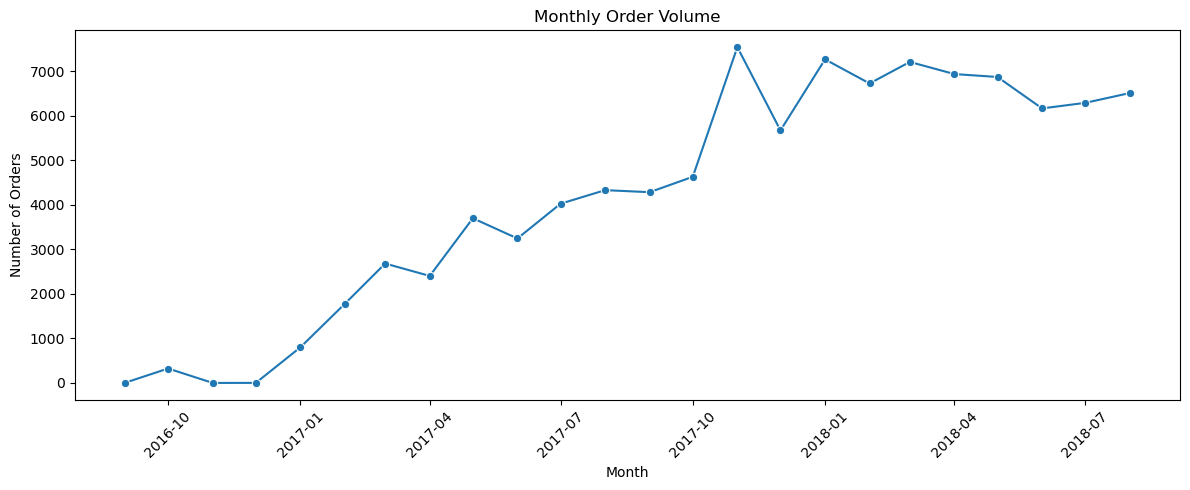

In [13]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales_complete,
    x="order_purchase_timestamp",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

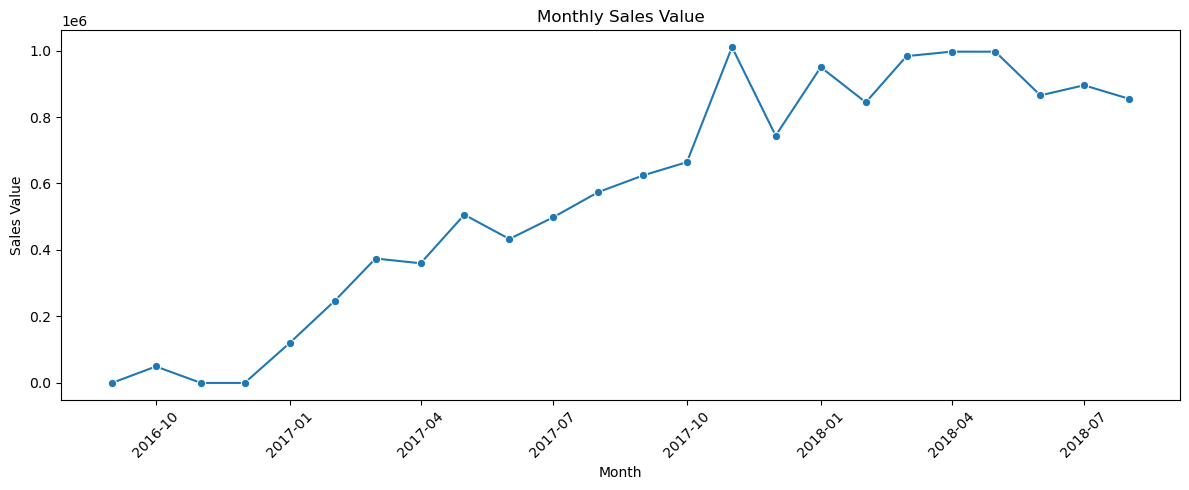

In [14]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales_complete,
    x="order_purchase_timestamp",
    y="total_sales",
    marker="o"
)

plt.title("Monthly Sales Value")
plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()